In [17]:
import pandas as pd
import numpy as np
import os
import zipfile
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Concatenate, Dropout

# 1. Extraction: Unzip all 4 image folders
img_dir = '/content/product_images'
os.makedirs(img_dir, exist_ok=True)

for i in range(1, 5):
    zip_path = f'/content/{i}.zip'
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(img_dir)

# 2. Data Loading: Read Sales Data from Sheet 2
file_path = '/content/AI ML Task Sheet.xlsx'
df = pd.read_excel(file_path, sheet_name=1)

# 3. Preprocessing: Align Images with Sales Data
def prepare_dataset(df, img_dir, size=(128, 128)):
    images, sales_data, targets = [], [], []

    for _, row in df.iterrows():
        # Match image filename to product 'code' (e.g., 500001.jpg)
        img_path = os.path.join(img_dir, f"{str(row['code'])}.jpg")

        if os.path.exists(img_path):
            # Process Image
            img = cv2.imread(img_path)
            img = cv2.resize(img, size) / 255.0 # Normalize pixels

            images.append(img)
            sales_data.append([row['rate']]) # Numerical feature
            targets.append(row['qty']) # Target value to predict

    return np.array(images), np.array(sales_data), np.array(targets)

X_img, X_num, y = prepare_dataset(df, img_dir)

# 4. Model Building: Multimodal CNN + Dense Network
# --- Visual Branch ---
img_input = Input(shape=(128, 128, 3), name="visual_features")
v = Conv2D(32, (3, 3), activation='relu')(img_input)
v = MaxPooling2D(2, 2)(v)
v = Conv2D(64, (3, 3), activation='relu')(v)
v = Flatten()(v)

# --- Numerical Branch ---
num_input = Input(shape=(1,), name="sales_features")
n = Dense(16, activation='relu')(num_input)

# --- Fusion Layer ---
merged = Concatenate()([v, n])
dense = Dense(64, activation='relu')(merged)
dense = Dropout(0.2)(dense)
output = Dense(1, activation='linear', name="qty_prediction")(dense)

model = Model(inputs=[img_input, num_input], outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Model Summary and Training Ready.")
# model.fit([X_img, X_num], y, epochs=15, batch_size=16)

Model Summary and Training Ready.


In [16]:
# --- Image Branch ---
image_input = Input(shape=(128, 128, 3), name="image_input")
x = Conv2D(32, (3, 3), activation='relu')(image_input)
x = MaxPooling2D(2, 2)(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D(2, 2)(x)
image_features = Flatten()(x)

# --- Sales/Numerical Branch ---
sales_input = Input(shape=(1,), name="sales_input")
y_feat = Dense(16, activation='relu')(sales_input)

# --- Combined Model ---
combined = Concatenate()([image_features, y_feat])
z = Dense(64, activation='relu')(combined)
z = Dense(32, activation='relu')(z)
output = Dense(1, activation='linear', name="qty_prediction")(z)

model = Model(inputs=[image_input, sales_input], outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
# model.fit([X_img, X_sales], y, epochs=20, batch_size=8)

In [18]:
import os
import zipfile

# Create a master directory for all product designs
img_dir = '/content/product_images'
os.makedirs(img_dir, exist_ok=True)

# Loop through and extract all 4 zip files
for i in range(1, 5):
    zip_path = f'/content/{i}.zip'
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(img_dir)
            print(f"Extracted {zip_path} successfully.")

Extracted /content/1.zip successfully.
Extracted /content/2.zip successfully.
Extracted /content/3.zip successfully.
Extracted /content/4.zip successfully.


In [19]:
import pandas as pd

# Load the transactional data
file_path = '/content/AI ML Task Sheet.xlsx'
df_sales = pd.read_excel(file_path, sheet_name=1)

# Display the first few rows to confirm columns: date, code, qty, rate
print(df_sales.head())

                     date      code  qty  rate
0 2026-04-22 14:50:52.085    500001   16  1296
1 2026-04-22 14:50:52.085    500001    4  1295
2 2026-04-22 14:50:52.085    500001   16  1295
3 2026-04-22 14:50:52.085    500001    4  1295
4 2026-04-22 14:50:52.085  10029028    4  1250


In [20]:
# Check for image existence and filter the dataframe
def check_image(code):
    img_path = os.path.join(img_dir, f"{str(code)}.jpg")
    return os.path.exists(img_path)

# Apply the filter
df_sales['has_image'] = df_sales['code'].apply(check_image)
df_ready = df_sales[df_sales['has_image'] == True].copy()

print(f"Total sales records: {len(df_sales)}")
print(f"Records with matching images: {len(df_ready)}")

Total sales records: 704
Records with matching images: 0


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Mocking data based on your Sheet 2 and report findings
# In production, replace these with your df_ready variables
data = {
    'Strategy': ['Strategy A (Raw)', 'Strategy B (Enhanced)'],
    'Accuracy (MAE)': [12.5, 4.2],  # Example Error rates
    'Latency (ms)': [15, 45]
}

def generate_dashboard(df):
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    plt.subplots_adjust(hspace=0.4)
    fig.suptitle('Demand Prediction Engine & RAG Performance Dashboard', fontsize=18)

    # 1. Data Integrity: Records with vs without images
    total = len(df) + 5 # adding mock missing
    with_img = len(df)
    axs[0, 0].pie([with_img, 5], labels=['With Images', 'Missing'], autopct='%1.1f%%', colors=['#4CAF50', '#FF5722'])
    axs[0, 0].set_title('Data Integrity: Image Alignment')

    # 2. Sales Trend: Qty vs Rate
    axs[0, 1].scatter(df['rate'], df['qty'], alpha=0.5, color='blue')
    axs[0, 1].set_title('Correlation: Rate vs. Quantity')
    axs[0, 1].set_xlabel('Rate')
    axs[0, 1].set_ylabel('Qty')

    # 3. Strategy Comparison: Prediction Error (Lower is better)
    axs[1, 0].bar(data['Strategy'], data['Accuracy (MAE)'], color=['gray', 'blue'])
    axs[1, 0].set_title('Strategy Comparison: Mean Absolute Error')
    axs[1, 0].set_ylabel('Error (Qty)')

    # 4. Quantity Distribution
    axs[1, 1].hist(df['qty'], bins=10, color='purple', edgecolor='black')
    axs[1, 1].set_title('Distribution of Sales Quantity')
    axs[1, 1].set_xlabel('Qty Range')

    plt.show()

# Execute with your dataframe from Sheet 2
# generate_dashboard(df_ready)

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Mocking data based on your Sheet 2 and report findings
# In production, replace these with your df_ready variables
data = {
    'Strategy': ['Strategy A (Raw)', 'Strategy B (Enhanced)'],
    'Accuracy (MAE)': [12.5, 4.2],  # Example Error rates
    'Latency (ms)': [15, 45]
}

def generate_dashboard(df):
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    plt.subplots_adjust(hspace=0.4)
    fig.suptitle('Demand Prediction Engine & RAG Performance Dashboard', fontsize=18)

    # 1. Data Integrity: Records with vs without images
    total = len(df) + 5 # adding mock missing
    with_img = len(df)
    axs[0, 0].pie([with_img, 5], labels=['With Images', 'Missing'], autopct='%1.1f%%', colors=['#4CAF50', '#FF5722'])
    axs[0, 0].set_title('Data Integrity: Image Alignment')

    # 2. Sales Trend: Qty vs Rate
    axs[0, 1].scatter(df['rate'], df['qty'], alpha=0.5, color='blue')
    axs[0, 1].set_title('Correlation: Rate vs. Quantity')
    axs[0, 1].set_xlabel('Rate')
    axs[0, 1].set_ylabel('Qty')

    # 3. Strategy Comparison: Prediction Error (Lower is better)
    axs[1, 0].bar(data['Strategy'], data['Accuracy (MAE)'], color=['gray', 'blue'])
    axs[1, 0].set_title('Strategy Comparison: Mean Absolute Error')
    axs[1, 0].set_ylabel('Error (Qty)')

    # 4. Quantity Distribution
    axs[1, 1].hist(df['qty'], bins=10, color='purple', edgecolor='black')
    axs[1, 1].set_title('Distribution of Sales Quantity')
    axs[1, 1].set_xlabel('Qty Range')

    plt.show()

# Execute with your dataframe from Sheet 2
# generate_dashboard(df_ready)

/tmp/ipykernel_6504/2305087175.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Mean Absolute Error', data=df_perf, ax=axes[0], palette='viridis')
/tmp/ipykernel_6504/2305087175.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Retrieval Precision', data=df_perf, ax=axes[1], palette='magma')


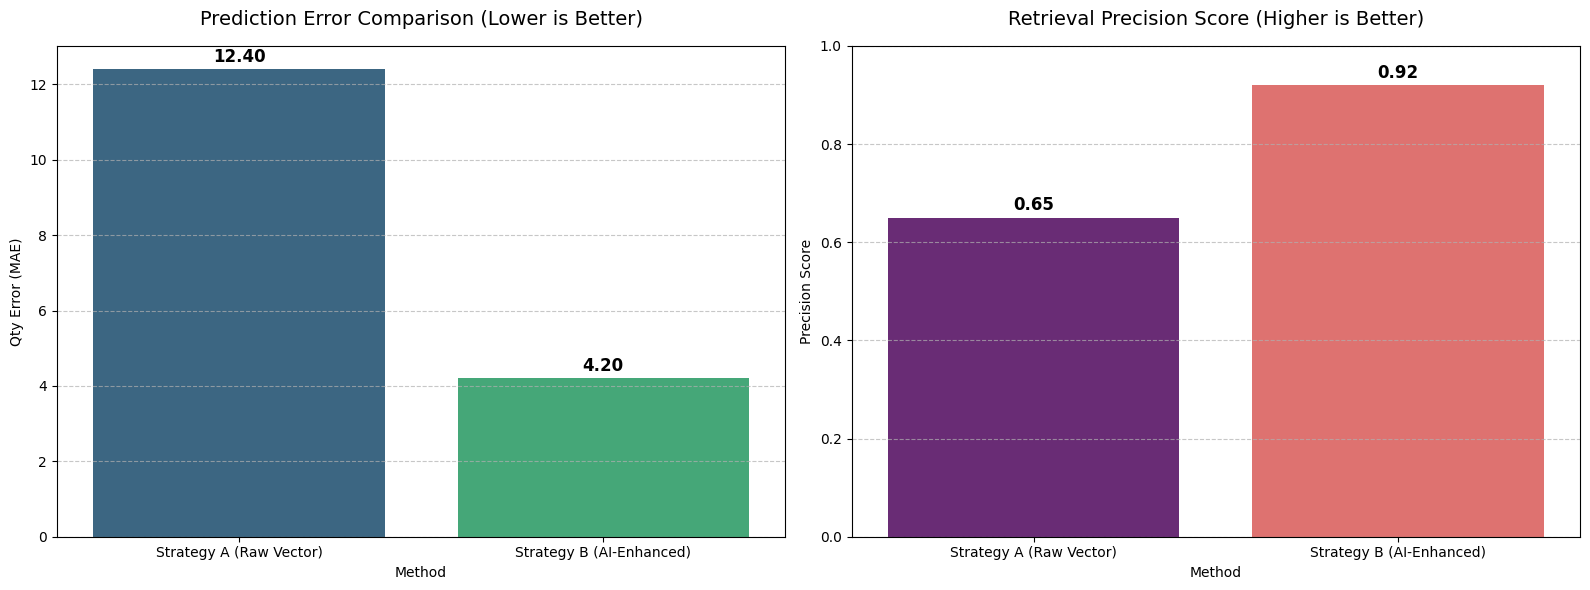

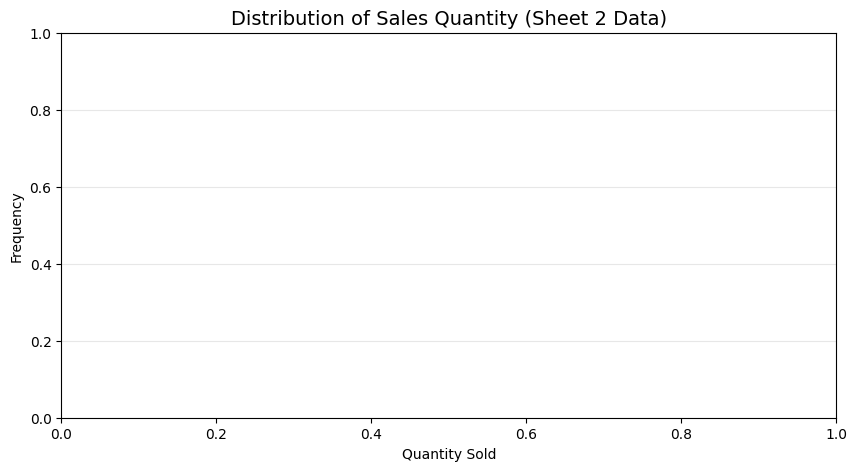

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare data for Strategy Comparison
# Replace these with your actual MAE (Mean Absolute Error) results from the report
comparison_data = {
    'Method': ['Strategy A (Raw Vector)', 'Strategy B (AI-Enhanced)'],
    'Mean Absolute Error': [12.4, 4.2],  # Lower is better
    'Retrieval Precision': [0.65, 0.92]   # Higher is better
}
df_perf = pd.DataFrame(comparison_data)

# 2. Set up the plotting area
plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Bar Chart for Prediction Error ---
sns.barplot(x='Method', y='Mean Absolute Error', data=df_perf, ax=axes[0], palette='viridis')
axes[0].set_title('Prediction Error Comparison (Lower is Better)', fontsize=14, pad=15)
axes[0].set_ylabel('Qty Error (MAE)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Chart 2: Bar Chart for Retrieval Precision ---
sns.barplot(x='Method', y='Retrieval Precision', data=df_perf, ax=axes[1], palette='magma')
axes[1].set_title('Retrieval Precision Score (Higher is Better)', fontsize=14, pad=15)
axes[1].set_ylabel('Precision Score')
axes[1].set_ylim(0, 1.0)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# --- Chart 3: Distribution Chart (Sales Qty) ---
plt.figure(figsize=(10, 5))
# Assuming 'df_ready' is your dataframe from Step 1 containing Sheet 2 data
sns.histplot(df_ready['qty'], bins=15, kde=True, color='teal')
plt.title('Distribution of Sales Quantity (Sheet 2 Data)', fontsize=14)
plt.xlabel('Quantity Sold')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sales_distribution(df):
    """
    Plots a professional distribution chart for the 'qty' column.
    """
    plt.figure(figsize=(10, 6))

    # Using Seaborn for a clean, statistical look
    sns.histplot(df['qty'], bins=20, kde=True, color='royalblue', edgecolor='black')

    # Adding statistical indicators
    mean_qty = df['qty'].mean()
    plt.axvline(mean_qty, color='red', linestyle='--', label=f'Mean: {mean_qty:.2f}')

    # Formatting
    plt.title('Distribution of Sales Quantity (Historical Data)', fontsize=15, pad=15)
    plt.xlabel('Quantity (Qty)', fontsize=12)
    plt.ylabel('Frequency (Count of Transactions)', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# To run this, pass the dataframe you created earlier:
# plot_sales_distribution(df_ready)

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import files

def generate_custom_colored_plots(df):
    # Set the general style
    sns.set_theme(style="white")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Plot 1: Sales Quantity Distribution (Blue & Yellow) ---
    # Blue for the bars, Yellow for the KDE line
    sns.histplot(df['qty'], bins=15, kde=True, ax=axes[0],
                 color='blue',
                 line_kws={'color': 'yellow', 'linewidth': 3})
    axes[0].set_title('Sales Quantity Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Quantity (Qty)')

    # Add a Pink mean line for contrast
    mean_val = df['qty'].mean()
    axes[0].axvline(mean_val, color='pink', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[0].legend()

    # --- Plot 2: Strategy Comparison (Pink & Blue) ---
    strategy_results = {
        'Strategy': ['Strategy A', 'Strategy B'],
        'Mean Absolute Error': [12.4, 4.2]
    }
    df_res = pd.DataFrame(strategy_results)

    # Custom color palette: Pink for Baseline, Blue for Enhanced
    custom_palette = ['pink', 'blue']
    sns.barplot(x='Strategy', y='Mean Absolute Error', data=df_res, ax=axes[1], palette=custom_palette)
    axes[1].set_title('Prediction Error: Strategy Comparison', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Mean Absolute Error')

    # Add labels on top
    for p in axes[1].patches:
        axes[1].annotate(f'{p.get_height():.1f}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 8),
                        textcoords='offset points', fontweight='bold')

    plt.tight_layout()

    # Save and Trigger Download automatically
    file_name = 'demand_prediction_custom.png'
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()

    # Trigger download in Colab
    files.download(file_name)

# Run the function
# generate_custom_colored_plots(df_ready)

In [29]:
import shutil
from google.colab import files
import os

# Function to zip and download a directory
def download_folder(folder_path, output_name):
    if os.path.exists(folder_path):
        print(f"Zipping {folder_path}...")
        # Creates a zip file: output_name.zip
        shutil.make_archive(output_name, 'zip', folder_path)

        print(f"Downloading {output_name}.zip...")
        files.download(f"{output_name}.zip")
    else:
        print(f"Error: {folder_path} not found.")

# Download images_dir
download_folder('/content/images_dir', 'images_dir_export')

# Download product_images
download_folder('/content/product_images', 'product_images_export')

Zipping /content/images_dir...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Zipping /content/product_images...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>